# Deep Learning 3

## Otimizadores no PyTorch

Link Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ftl-brazil-2026/ebook/blob/main/deep-learning/dl3_otimizadores.ipynb)

Na aula 2 treinamos o MLP do MNIST escrevendo a atualização à mão:

```python
with torch.no_grad():
    for p in modelo.parameters():
        p -= eta * p.grad
        p.grad.zero_()
```

Hoje vamos ver que um **otimizador** do PyTorch é exatamente isso: **o objeto que aplica a atualização**.
A vantagem é que trocar a regra de atualização (SGD, *momentum*, Adam...) passa a ser trocar uma linha.

**Roteiro**

1. `torch.optim.SGD` é a regra da aula 2
2. O padrão `zero_grad() → backward() → step()`, e por que o `zero_grad` existe
3. *Momentum* e Adam na paisagem 2D da aula 2
4. SGD × *momentum* × Adam treinando o MNIST
5. Sensibilidade à taxa de aprendizado
6. De volta ao Teorema da Aproximação Universal: aproximando qualquer função

In [ ]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


AZUL, LARANJA, VERDE, CINZA, TINTA = "#2a78d6", "#eb6834", "#1baf7a", "#898781", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": CINZA, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.grid": True, "grid.color": "#e6e5e1", "figure.dpi": 110,
})

torch.manual_seed(42)

treino = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
teste = datasets.MNIST(root="data", train=False, download=True, transform=transforms.ToTensor())

def cria_mlp():
    return nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))

def acuracia(modelo, dataset, n=10000):
    x, y = next(iter(DataLoader(dataset, batch_size=n)))
    with torch.no_grad():
        return (modelo(x).argmax(dim=1) == y).float().mean().item()

## 1. `torch.optim.SGD` é a regra da aula 2

Vamos provar: duas cópias **idênticas** da rede, o mesmo lote de imagens. Na cópia A aplicamos a atualização
à mão; na cópia B usamos `torch.optim.SGD(..., lr=0.1)`. Os pesos resultantes têm que ser iguais.

In [ ]:
torch.manual_seed(0)
modelo_a = cria_mlp()
modelo_b = copy.deepcopy(modelo_a)            # cópia com os mesmos pesos
x_lote, y_lote = next(iter(DataLoader(treino, batch_size=64, shuffle=True)))
eta = 0.1

# A: atualização à mão (aula 2)
F.cross_entropy(modelo_a(x_lote), y_lote).backward()
with torch.no_grad():
    for p in modelo_a.parameters():
        p -= eta * p.grad

# B: otimizador do PyTorch
otimizador = torch.optim.SGD(modelo_b.parameters(), 
                             lr=eta
                             )
F.cross_entropy(modelo_b(x_lote), y_lote).backward()
otimizador.step()

iguais = all(torch.allclose(pa, pb) for pa, pb in zip(modelo_a.parameters(), modelo_b.parameters()))
print(f"Os pesos das duas redes são iguais depois da atualização? {iguais}")

Os pesos das duas redes são iguais depois da atualização? True


O otimizador recebe a lista de parâmetros (`modelo.parameters()`) quando é criado. Depois disso:

- `otimizador.step()` aplica a regra de atualização a todos eles, usando o `.grad` de cada um;
- `otimizador.zero_grad()` zera todos os `.grad`.

## 2. O padrão de todo treino em PyTorch

Todo laço de treino em PyTorch tem estas três linhas, nesta ordem:

```python
otimizador.zero_grad()   # 1. apaga os gradientes do passo anterior
perda.backward()         # 2. calcula os novos gradientes
otimizador.step()        # 3. atualiza os pesos
```

### Por que precisamos do `zero_grad()`?

Porque o PyTorch **acumula** (soma) os gradientes: cada `backward()` **adiciona** ao `.grad` que já existe, em
vez de substituir. Veja o que acontece chamando `backward()` duas vezes sem zerar:

In [3]:
torch.manual_seed(0)
modelo = cria_mlp()
peso = modelo[1].weight                       # pesos da primeira camada

F.cross_entropy(modelo(x_lote), y_lote).backward()
grad_1 = peso.grad.clone()

F.cross_entropy(modelo(x_lote), y_lote).backward()      # mesmo lote, sem zerar
grad_2 = peso.grad.clone()

print(f"depois do 1º backward: soma |grad| = {grad_1.abs().sum():.4f}")
print(f"depois do 2º backward: soma |grad| = {grad_2.abs().sum():.4f}")
print(f"razão: {grad_2.abs().sum() / grad_1.abs().sum():.2f}  (o gradiente dobrou!)")

otimizador = torch.optim.SGD(modelo.parameters(), lr=0.1)
otimizador.zero_grad()
print(f"\ndepois do zero_grad(): {peso.grad}")

depois do 1º backward: soma |grad| = 98.6423
depois do 2º backward: soma |grad| = 197.2846
razão: 2.00  (o gradiente dobrou!)

depois do zero_grad(): None


Sem o `zero_grad()`, cada passo usaria a soma de **todos** os gradientes anteriores: os passos ficariam cada vez
maiores e apontando para direções antigas. O treino degringola. (Esse acúmulo é útil em um caso avançado,
*gradient accumulation*, para simular lotes grandes demais para a memória. Por isso o PyTorch não zera sozinho.)

## *Momentum* e Adam

Na aula 2, a descida do gradiente fazia **zigue-zague** no vale alongado. Os otimizadores modernos mudam a
regra de atualização para lidar com isso.

### SGD com *momentum*: uma bola rolando morro abaixo

Em vez de usar só o gradiente do passo atual, acumulamos uma **velocidade** $v$, uma média dos gradientes
recentes:

$$v \leftarrow \beta\, v + \nabla L(\theta) \qquad \theta \leftarrow \theta - \eta\, v$$

Com $\beta$ (tipicamente 0,9), os componentes que **trocam de sinal** a cada passo (o zigue-zague) se
cancelam, e os que **apontam sempre para o mesmo lado** se somam e aceleram.

### Adam: uma taxa de aprendizado para cada parâmetro

O Adam guarda duas médias móveis por parâmetro: a do gradiente $m$ (como o *momentum*) e a do gradiente **ao
quadrado** $s$. A atualização divide uma pela outra:

$$\theta \leftarrow \theta - \eta \, \frac{m}{\sqrt{s} + \epsilon}$$

Parâmetros com gradientes grandes dão passos menores; parâmetros com gradientes pequenos dão passos
maiores. Na prática, cada parâmetro tem sua própria taxa de aprendizado. O Adam é o **padrão sensato** para
começar qualquer projeto (com `lr=1e-3`).

### Comparando na paisagem da aula 2

Mesma perda $L(\theta_1, \theta_2) = \theta_1^2 + 25\,\theta_2^2$, mesmo ponto de partida e 60 passos de cada
otimizador. Aqui os otimizadores do PyTorch atualizam um tensor com 2 parâmetros, exatamente como fariam com os
pesos de uma rede.

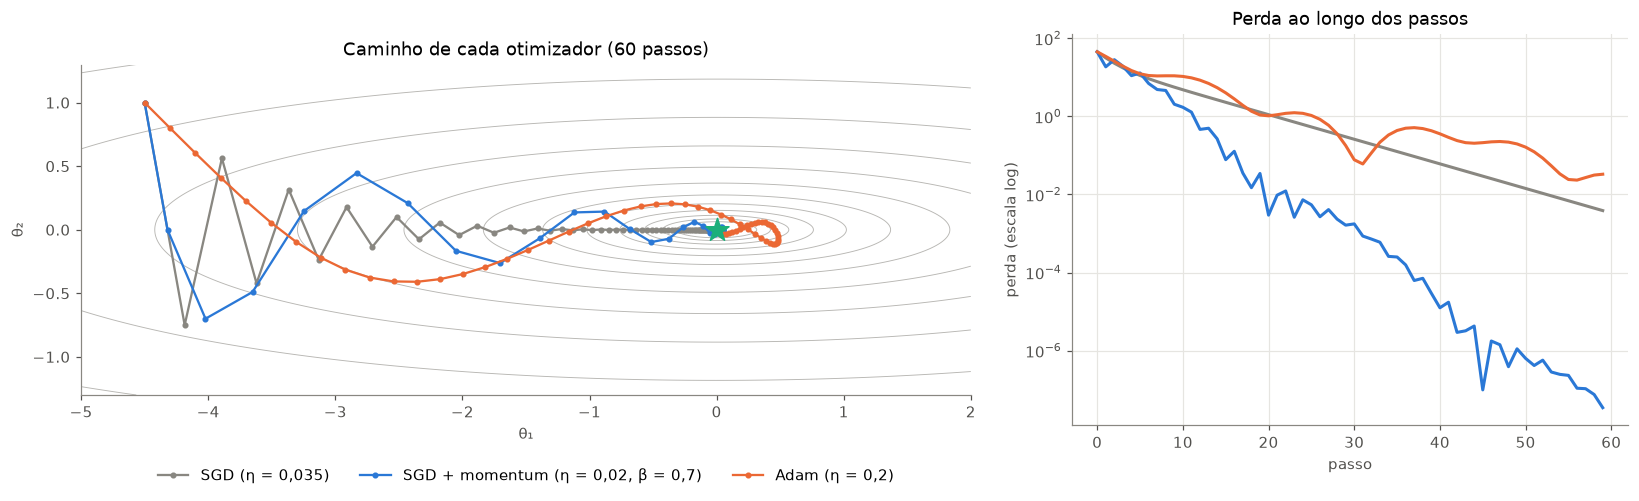

SGD (η = 0,035)                      perda após 20 passos = 1.285   após 60 = 0.00387
SGD + momentum (η = 0,02, β = 0,7)   perda após 20 passos = 0.035   após 60 = 0.00000
Adam (η = 0,2)                       perda após 20 passos = 1.088   após 60 = 0.03307


In [4]:
def perda_2d(t):
    return t[0] ** 2 + 25 * t[1] ** 2

def trajetoria(cria_otimizador, passos=60):
    theta = torch.tensor([-4.5, 1.0], requires_grad=True)
    otimizador = cria_otimizador([theta])
    caminho, perdas = [theta.detach().clone()], []
    for _ in range(passos):
        otimizador.zero_grad()
        perda = perda_2d(theta)
        perda.backward()
        otimizador.step()
        caminho.append(theta.detach().clone())
        perdas.append(perda.item())
    return torch.stack(caminho).numpy(), np.array(perdas)

configs_2d = {
    "SGD (η = 0,035)": (lambda p: torch.optim.SGD(p, lr=0.035), CINZA),
    "SGD + momentum (η = 0,02, β = 0,7)": (lambda p: torch.optim.SGD(p, lr=0.02, momentum=0.7), AZUL),
    "Adam (η = 0,2)": (lambda p: torch.optim.Adam(p, lr=0.2), LARANJA),
}
resultados_2d = {nome: trajetoria(f) for nome, (f, _) in configs_2d.items()}

T1, T2 = np.meshgrid(np.linspace(-5, 2, 300), np.linspace(-1.3, 1.3, 300))
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), width_ratios=[1.6, 1])
axes[0].contour(T1, T2, T1 ** 2 + 25 * T2 ** 2, levels=np.logspace(-1, 1.8, 12), colors=CINZA, linewidths=0.6, alpha=0.6)
for nome, (caminho, perdas) in resultados_2d.items():
    cor = configs_2d[nome][1]
    axes[0].plot(caminho[:, 0], caminho[:, 1], color=cor, marker="o", ms=3, lw=1.5, label=nome)
    axes[1].plot(perdas, color=cor, lw=2, label=nome)
axes[0].scatter(0, 0, marker="*", s=250, color=VERDE, zorder=3)
axes[0].set(xlabel="θ₁", ylabel="θ₂", title="Caminho de cada otimizador (60 passos)")
axes[0].set_aspect("equal")
axes[0].grid(False)
axes[0].legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncols=3)
axes[1].set(yscale="log", xlabel="passo", ylabel="perda (escala log)", title="Perda ao longo dos passos")
plt.tight_layout()
plt.show()

for nome, (_, perdas) in resultados_2d.items():
    print(f"{nome:<36} perda após 20 passos = {perdas[19]:.3f}   após 60 = {perdas[-1]:.5f}")

**Leitura:**

- **SGD** faz zigue-zague na direção íngreme ($\theta_2$). Não dá para aumentar η sem divergir nessa direção, e
  por isso ele anda devagar na direção plana ($\theta_1$).
- **Momentum** também oscila no começo, mas as oscilações se cancelam rapidamente enquanto a velocidade se
  acumula na direção plana: depois de 20 passos, a perda já é dezenas de vezes menor que a do SGD.
- **Adam** começa andando na **diagonal**: como ele normaliza cada parâmetro pelo tamanho do próprio gradiente, os
  primeiros passos têm o mesmo tamanho nas duas direções. Nesta paisagem simples ele não é o mais rápido. A
  vantagem real do Adam aparece em redes de verdade, com milhares de parâmetros em escalas diferentes, e na
  **robustez à escolha de η**, como veremos no MNIST.

## SGD × *momentum* × Adam treinando o MNIST

Agora a comparação que importa: o mesmo MLP, **os mesmos pesos iniciais**, os mesmos lotes na mesma ordem,
2 épocas para cada otimizador. Uma **época** é uma passada completa pelas 60 mil imagens de treino (938 lotes de 64).

Repare que o laço de treino é **idêntico** para os três: só muda a linha que cria o otimizador.

In [5]:
torch.manual_seed(0)
pesos_iniciais = cria_mlp().state_dict()     # todos os otimizadores partem dos mesmos pesos

def treina(cria_otimizador, epocas=2, seed=0):
    modelo = cria_mlp()
    modelo.load_state_dict(pesos_iniciais)
    otimizador = cria_otimizador(modelo.parameters())
    gerador = torch.Generator().manual_seed(seed)          # mesma ordem de lotes para todos
    carregador = DataLoader(treino, batch_size=64, shuffle=True, generator=gerador)
    historico = []
    for _ in range(epocas):
        for x, y in carregador:
            otimizador.zero_grad()                         # 1
            perda = F.cross_entropy(modelo(x), y)
            perda.backward()                               # 2
            otimizador.step()                              # 3
            historico.append(perda.item())
    return modelo, np.array(historico)

configs_mnist = {
    "SGD (lr = 0,05)": (lambda p: torch.optim.SGD(p, lr=0.05), CINZA),
    "SGD + momentum (lr = 0,05, β = 0,9)": (lambda p: torch.optim.SGD(p, lr=0.05, momentum=0.9), AZUL),
    "Adam (lr = 0,001)": (lambda p: torch.optim.Adam(p, lr=1e-3), LARANJA),
}
resultados_mnist = {}
for nome, (cria_otimizador, _) in configs_mnist.items():
    modelo, historico = treina(cria_otimizador)
    resultados_mnist[nome] = (modelo, historico)
    print(f"{nome:<36} acurácia no teste = {acuracia(modelo, teste):.2%}")

SGD (lr = 0,05)                      acurácia no teste = 92.82%


SGD + momentum (lr = 0,05, β = 0,9)  acurácia no teste = 97.04%


Adam (lr = 0,001)                    acurácia no teste = 96.24%


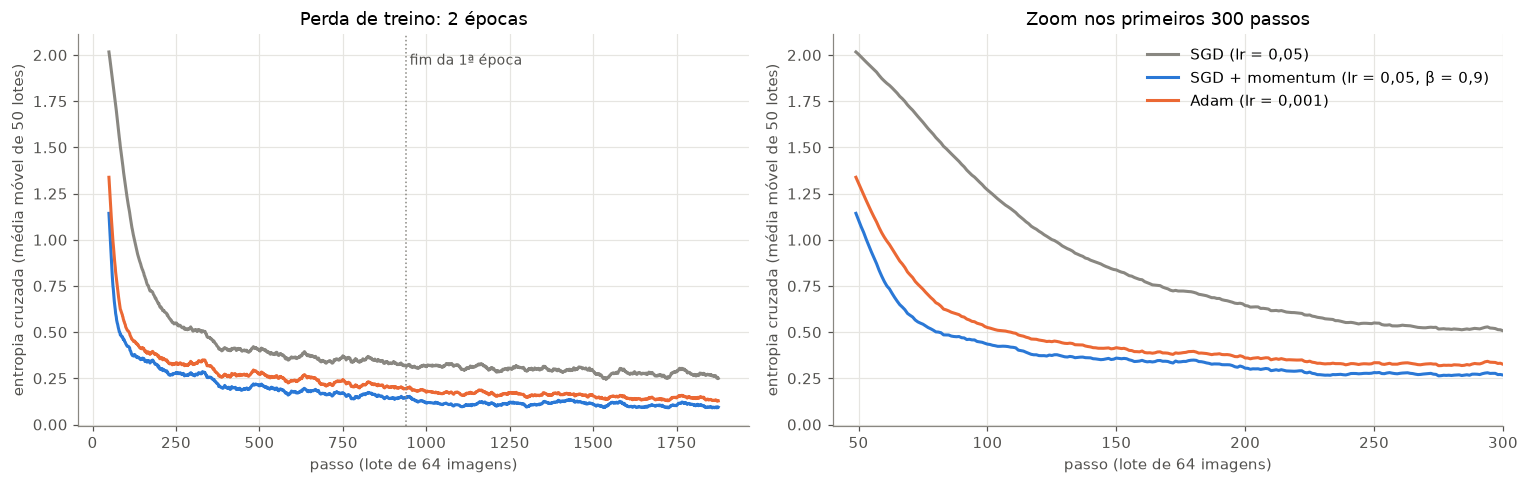

In [6]:
def suaviza(serie, janela=50):
    return np.convolve(serie, np.ones(janela) / janela, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for nome, (_, historico) in resultados_mnist.items():
    cor = configs_mnist[nome][1]
    for ax in axes:
        ax.plot(np.arange(len(suaviza(historico))) + 49, suaviza(historico), color=cor, lw=2, label=nome)
lotes_por_epoca = len(historico) // 2
for ax in axes:
    ax.axvline(lotes_por_epoca, color=CINZA, ls=":", lw=1)
    ax.set(xlabel="passo (lote de 64 imagens)", ylabel="entropia cruzada (média móvel de 50 lotes)")
axes[0].set_title("Perda de treino: 2 épocas")
axes[0].text(lotes_por_epoca, axes[0].get_ylim()[1] * 0.95, " fim da 1ª época", color=TINTA, fontsize=9, va="top")
axes[1].set(title="Zoom nos primeiros 300 passos", xlim=(40, 300))
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

## Sensibilidade à taxa de aprendizado

A comparação acima depende do η escolhido para cada otimizador. Para uma comparação justa, treinamos 1 época
com várias taxas de aprendizado e olhamos a acurácia no teste. (Esta célula leva cerca de 20 segundos.)

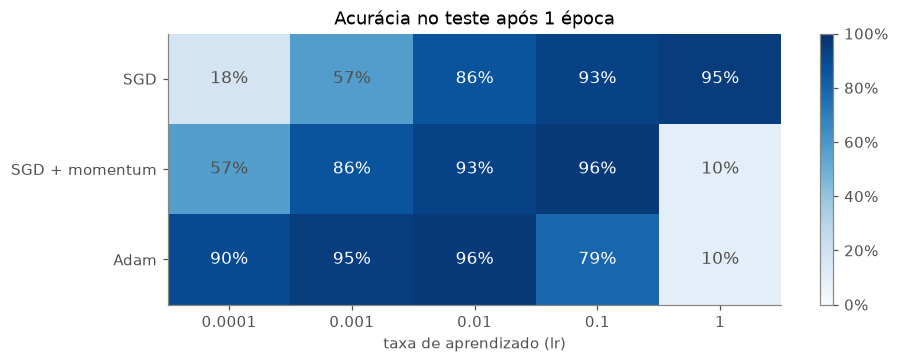

In [7]:
taxas = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
otimizadores = {
    "SGD": lambda p, lr: torch.optim.SGD(p, lr=lr),
    "SGD + momentum": lambda p, lr: torch.optim.SGD(p, lr=lr, momentum=0.9),
    "Adam": lambda p, lr: torch.optim.Adam(p, lr=lr),
}
grade = pd.DataFrame(index=otimizadores, columns=[f"{lr:g}" for lr in taxas], dtype=float)
for nome, f in otimizadores.items():
    for lr in taxas:
        modelo, _ = treina(lambda p: f(p, lr), epocas=1)
        grade.loc[nome, f"{lr:g}"] = acuracia(modelo, teste)

fig, ax = plt.subplots(figsize=(9, 3.2))
im = ax.imshow(grade.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
for i in range(grade.shape[0]):
    for j in range(grade.shape[1]):
        v = grade.iloc[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", color="white" if v > 0.6 else TINTA, fontsize=11)
ax.set(xticks=range(len(taxas)), xticklabels=grade.columns, yticks=range(len(otimizadores)), yticklabels=grade.index,
       xlabel="taxa de aprendizado (lr)", title="Acurácia no teste após 1 época")
ax.grid(False)
plt.colorbar(im, ax=ax, format=lambda v, _: f"{v:.0%}")
plt.show()

**Leitura:**

- Cada otimizador tem a sua **faixa boa** de taxa de aprendizado: o SGD puro precisa de η grande (0,1 a 1),
  o *momentum* funciona melhor com η uma ordem de grandeza menor, e o Adam vai bem entre 0,001 e 0,01.
- O Adam é o mais **tolerante**: ele já passa de 90% com η = 0,0001, enquanto o SGD puro fica perto do chute.
- Fora da faixa, todos falham: η pequeno demais não sai do lugar em 1 época; η grande demais diverge (o Adam
  com lr = 1 fica no chute aleatório).
- O padrão `Adam(lr=1e-3)` funciona bem "de primeira" na maioria dos problemas. Por isso ele é o ponto de
  partida recomendado.

## De volta ao Teorema da Aproximação Universal

Na aula 1 vimos o teorema:

> Uma rede com **uma camada escondida** e uma ativação não linear aproxima **qualquer função contínua** em um
> intervalo limitado, desde que tenha neurônios suficientes.

Lá, a função `treina` era uma caixa-preta. Agora sabemos exatamente o que ela faz: é o padrão
`zero_grad() depois backward() por fim isso é step()` com um otimizador. Vamos escrever uma função aproxima que recebe **qualquer
função** $f(x)$ e tenta aproximá-la com uma rede $1 \to n \to 1$ com ReLU:

1. sorteamos pontos $x$ no intervalo e calculamos $y = f(x)$: esse é o nosso "dataset";
2. criamos a rede com $n$ neurônios escondidos;
3. treinamos com a perda MSE (regressão, aula 2) e o otimizador que quisermos (esta aula).

In [ ]:
def aproxima(f, n_neuronios=64, intervalo=(-2, 2), passos=3000, n_pontos=500,
             cria_otimizador=lambda p: torch.optim.Adam(p, lr=0.01), seed=0):
    """Aproxima uma função f qualquer com uma rede 1 → n_neuronios → 1 (ReLU)."""
    torch.manual_seed(seed)
    x = torch.linspace(*intervalo, n_pontos).unsqueeze(1)       # (n_pontos, 1)
    y = f(x)
    rede = nn.Sequential(nn.Linear(1, n_neuronios), nn.ReLU(), nn.Linear(n_neuronios, 1))
    otimizador = cria_otimizador(rede.parameters())
    historico = []
    for _ in range(passos):
        otimizador.zero_grad()
        perda = F.mse_loss(rede(x), y)
        perda.backward()
        otimizador.step()
        historico.append(perda.item())
    return rede, np.array(historico)

### Uma galeria de funções

Seis funções bem diferentes: suaves, com "bico", cheias de oscilações e até **descontínuas** (que o teorema
**não** cobre). Cada uma é aproximada com 4, 32 e 256 neurônios. (Esta célula leva ~15 segundos.)

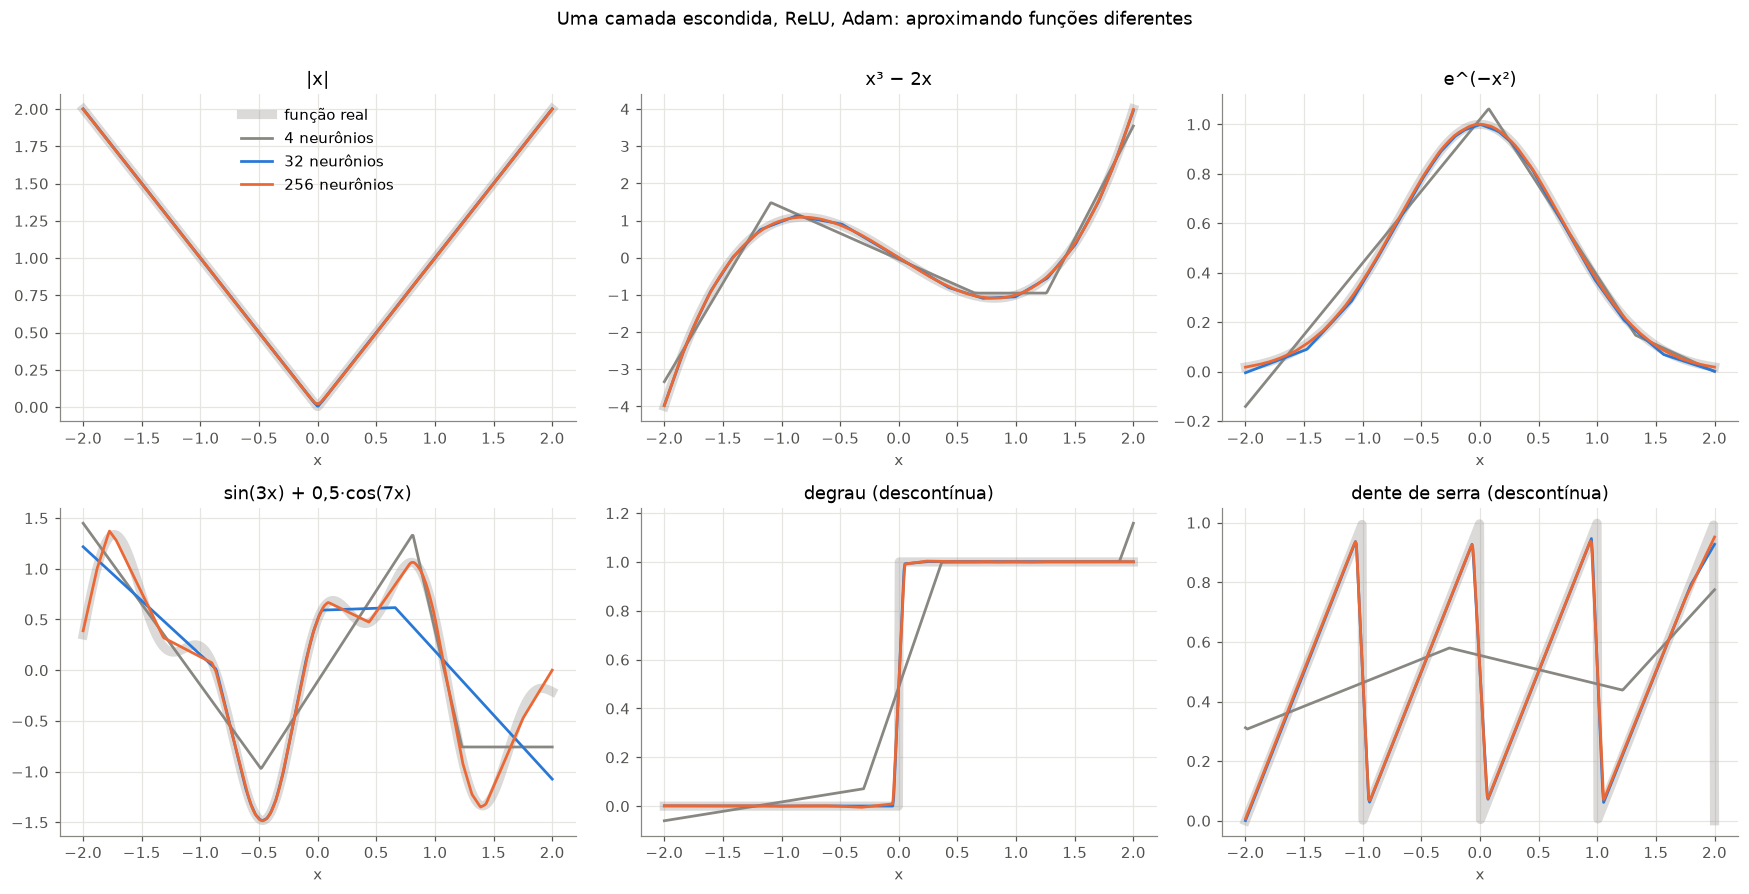

,4 neurônios,32 neurônios,256 neurônios
|x|,0.00000,0.00000,0.00003
x³ − 2x,0.04452,0.00031,0.00000
e^(−x²),0.00221,0.00005,0.00000
"sin(3x) + 0,5·cos(7x)",0.12614,0.15778,0.00265
degrau (descontínua),0.01582,0.00196,0.00209
dente de serra (descontínua),0.07069,0.00879,0.00942


In [9]:
funcoes = {
    "|x|": torch.abs,
    "x³ − 2x": lambda x: x ** 3 - 2 * x,
    "e^(−x²)": lambda x: torch.exp(-x ** 2),
    "sin(3x) + 0,5·cos(7x)": lambda x: torch.sin(3 * x) + 0.5 * torch.cos(7 * x),
    "degrau (descontínua)": lambda x: (x > 0).float(),
    "dente de serra (descontínua)": lambda x: x - torch.floor(x),
}
larguras = [4, 32, 256]
cores_largura = {4: CINZA, 32: AZUL, 256: LARANJA}

x_plot = torch.linspace(-2, 2, 500).unsqueeze(1)
erros_uat = pd.DataFrame(index=list(funcoes), columns=[f"{n} neurônios" for n in larguras], dtype=float)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (nome, f) in zip(axes.flat, funcoes.items()):
    ax.plot(x_plot, f(x_plot), color=CINZA, lw=6, alpha=0.3, label="função real")
    for n_neuronios in larguras:
        rede, historico = aproxima(f, n_neuronios)
        erros_uat.loc[nome, f"{n_neuronios} neurônios"] = historico[-1]
        with torch.no_grad():
            ax.plot(x_plot, rede(x_plot), color=cores_largura[n_neuronios], lw=1.8, label=f"{n_neuronios} neurônios")
    ax.set(title=nome, xlabel="x")
axes[0, 0].legend(frameon=False, loc="upper center")
plt.suptitle("Uma camada escondida, ReLU, Adam: aproximando funções diferentes", y=1.01)
plt.tight_layout()
plt.show()

erros_uat.style.format("{:.5f}").background_gradient(cmap="Blues", axis=None)

**Leitura:**

- Com **4 neurônios**, a rede só consegue fazer ~4 "dobras": serve para $|x|$ (uma dobra basta!), mas não
  para funções com muitas oscilações.
- Com **256 neurônios**, praticamente todas as funções contínuas ficam indistinguíveis da original.
- A função com oscilações rápidas, $\sin(3x) + 0{,}5\cos(7x)$, é a que mais precisa de neurônios: cada subida
  e descida consome dobras.
- As **descontínuas** (degrau, dente de serra) estão fora do teorema. A rede faz o que pode: troca cada salto por
  uma **rampa muito íngreme**, e o erro se concentra nos saltos.

### Limite 1: só vale **dentro do intervalo**

O teorema fala de um intervalo limitado. Fora dos pontos de treino, a rede não sabe nada sobre a função: com
ReLU, ela simplesmente continua em **linha reta**.

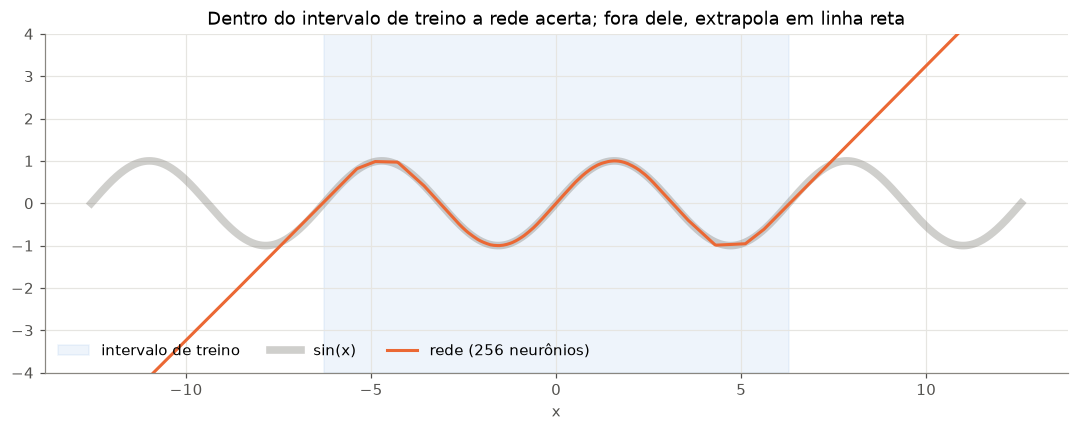

In [10]:
rede_sen, _ = aproxima(torch.sin, n_neuronios=256, intervalo=(-2 * np.pi, 2 * np.pi), passos=4000)

x_largo = torch.linspace(-4 * np.pi, 4 * np.pi, 800).unsqueeze(1)
fig, ax = plt.subplots(figsize=(12, 4))
ax.axvspan(-2 * np.pi, 2 * np.pi, color=AZUL, alpha=0.08, label="intervalo de treino")
ax.plot(x_largo, torch.sin(x_largo), color=CINZA, lw=5, alpha=0.4, label="sin(x)")
with torch.no_grad():
    ax.plot(x_largo, rede_sen(x_largo), color=LARANJA, lw=2, label="rede (256 neurônios)")
ax.set(xlabel="x", ylim=(-4, 4), title="Dentro do intervalo de treino a rede acerta; fora dele, extrapola em linha reta")
ax.legend(frameon=False, loc="lower left", ncols=3)
plt.show()

### Limite 2: existir uma solução ≠ conseguir encontrá-la

O teorema garante que **existem** pesos que aproximam a função, mas não diz como encontrá-los. Quem procura é o
**otimizador**. Mesma rede (256 neurônios), mesma função cheia de oscilações, mesmos pesos iniciais e mesmos
3.000 passos, mudando só o otimizador:

SGD (lr = 0,01)                        MSE final = 0.06749


SGD + momentum (lr = 0,01, β = 0,9)    MSE final = 0.01236


Adam (lr = 0,01)                       MSE final = 0.00265


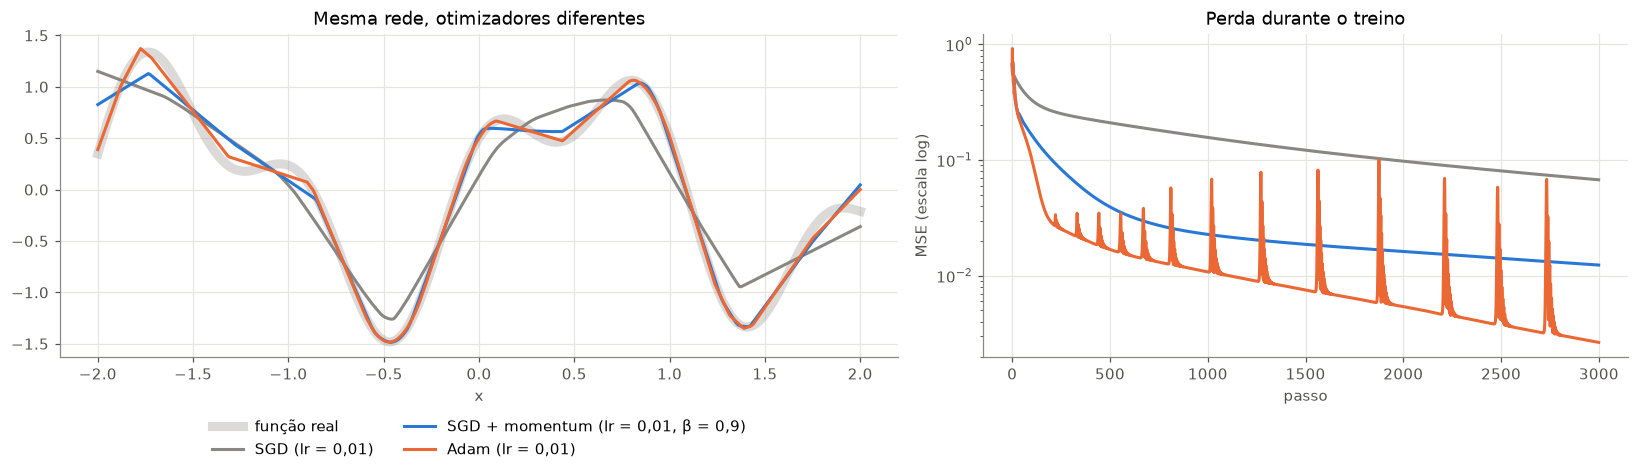

In [11]:
f_dificil = funcoes["sin(3x) + 0,5·cos(7x)"]
configs_uat = {
    "SGD (lr = 0,01)": (lambda p: torch.optim.SGD(p, lr=0.01), CINZA),
    "SGD + momentum (lr = 0,01, β = 0,9)": (lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9), AZUL),
    "Adam (lr = 0,01)": (lambda p: torch.optim.Adam(p, lr=0.01), LARANJA),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), width_ratios=[1.3, 1])
axes[0].plot(x_plot, f_dificil(x_plot), color=CINZA, lw=6, alpha=0.3, label="função real")
for nome, (cria_otimizador, cor) in configs_uat.items():
    rede, historico = aproxima(f_dificil, n_neuronios=256, cria_otimizador=cria_otimizador)
    with torch.no_grad():
        axes[0].plot(x_plot, rede(x_plot), color=cor, lw=2, label=nome)
    axes[1].plot(historico, color=cor, lw=2, label=nome)
    print(f"{nome:<38} MSE final = {historico[-1]:.5f}")
axes[0].set(xlabel="x", title="Mesma rede, otimizadores diferentes")
axes[0].legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncols=2)
axes[1].set(yscale="log", xlabel="passo", ylabel="MSE (escala log)", title="Perda durante o treino")
plt.tight_layout()
plt.show()

A rede é **a mesma** nos três casos: a capacidade de representar a função está lá. O que muda é se o
otimizador consegue chegar até os pesos certos em 3.000 passos. É por isso que o teorema, sozinho, não basta:
na prática, a escolha do **otimizador** e da **taxa de aprendizado** decide se a solução que existe é encontrada.

Os **picos** na curva do Adam são normais com uma taxa de aprendizado relativamente alta: de tempos em tempos
ele dá um passo grande demais, a perda sobe, e ele se recupera logo em seguida.

### E em mais dimensões?

O teorema vale para funções de várias variáveis. Basta trocar a entrada de 1 para 2 números: uma rede
$2 \to 256 \to 1$ aproximando a superfície $f(x, y) = \sin(x)\cos(y)$.

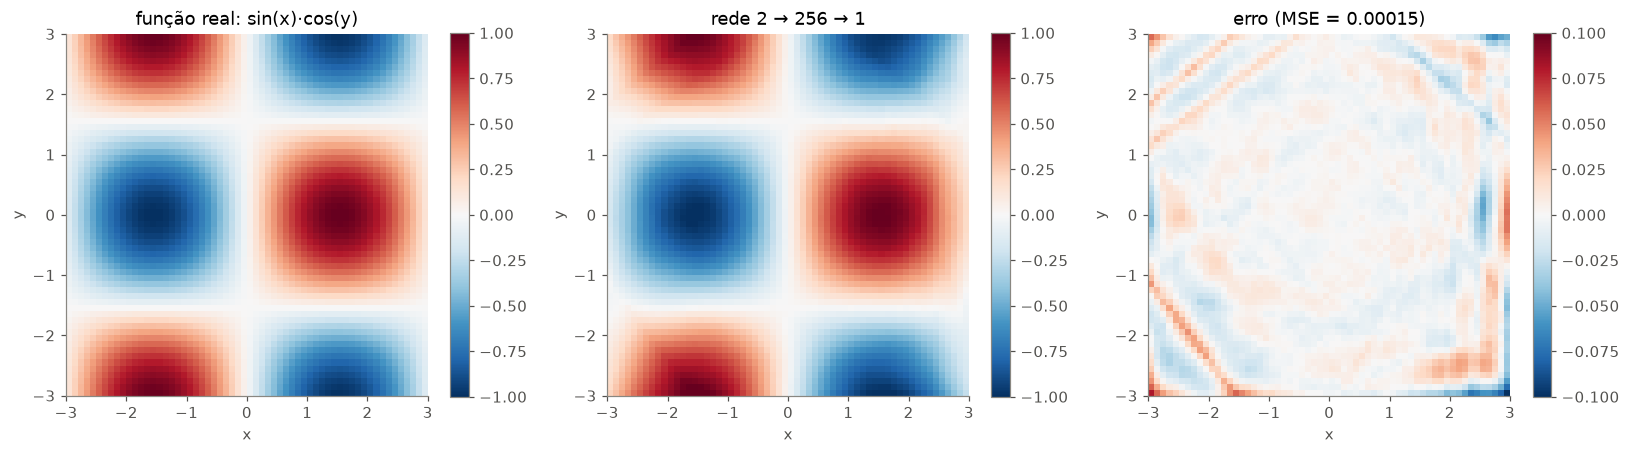

In [12]:
torch.manual_seed(0)
eixo = torch.linspace(-3, 3, 60)
X, Y = torch.meshgrid(eixo, eixo, indexing="xy")
entradas = torch.stack([X.flatten(), Y.flatten()], dim=1)       # (3600, 2): cada linha é um ponto (x, y)
alvo = (torch.sin(X) * torch.cos(Y)).flatten().unsqueeze(1)

rede_2d = nn.Sequential(nn.Linear(2, 256), nn.ReLU(), nn.Linear(256, 1))
otimizador = torch.optim.Adam(rede_2d.parameters(), lr=0.01)
for _ in range(3000):
    otimizador.zero_grad()
    perda = F.mse_loss(rede_2d(entradas), alvo)
    perda.backward()
    otimizador.step()

with torch.no_grad():
    previsto = rede_2d(entradas).reshape(60, 60)
real = alvo.reshape(60, 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
extensao = [-3, 3, -3, 3]
for ax, dados, titulo, cmap, lim in [
    (axes[0], real, "função real: sin(x)·cos(y)", "RdBu_r", 1),
    (axes[1], previsto, "rede 2 → 256 → 1", "RdBu_r", 1),
    (axes[2], previsto - real, f"erro (MSE = {perda.item():.5f})", "RdBu_r", 0.1),
]:
    im = ax.imshow(dados, extent=extensao, origin="lower", cmap=cmap, vmin=-lim, vmax=lim)
    ax.set(title=titulo, xlabel="x", ylabel="y")
    ax.grid(False)
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### Sua vez: aproxime qualquer função

Troque `minha_funcao` por qualquer função de `x` escrita com operações do PyTorch (`torch.sin`, `torch.exp`,
`torch.abs`, `**`, ...), escolha o número de neurônios e o intervalo, e veja até onde a rede chega.

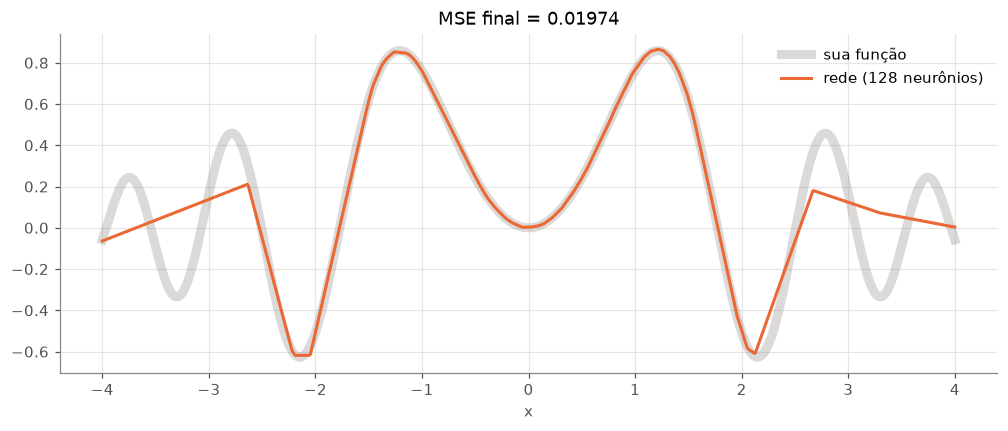

In [13]:
minha_funcao = lambda x: torch.sin(x ** 2) * torch.exp(-0.1 * x ** 2)   # ← troque aqui
N_NEURONIOS = 128
INTERVALO = (-4, 4)

rede, historico = aproxima(minha_funcao, n_neuronios=N_NEURONIOS, intervalo=INTERVALO, passos=4000)

x_sua = torch.linspace(*INTERVALO, 800).unsqueeze(1)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x_sua, minha_funcao(x_sua), color=CINZA, lw=6, alpha=0.3, label="sua função")
with torch.no_grad():
    ax.plot(x_sua, rede(x_sua), color=LARANJA, lw=2, label=f"rede ({N_NEURONIOS} neurônios)")
ax.set(xlabel="x", title=f"MSE final = {historico[-1]:.5f}")
ax.legend(frameon=False)
plt.show()

Com 128 neurônios e o intervalo $[-4, 4]$, a rede acerta o centro mas **não pega as oscilações rápidas das bordas**:
ali $\sin(x^2)$ oscila cada vez mais rápido e faltam "dobras". Experimente aumentar `N_NEURONIOS` (ou `passos`
dentro de `aproxima`) e veja quanto custa capturar as bordas.

## 7. Discussão

- O **otimizador** é o objeto que aplica a atualização dos pesos. `torch.optim.SGD` é exatamente a regra
  $\theta \leftarrow \theta - \eta \nabla L$ da aula 2.
- Todo treino em PyTorch segue o padrão `zero_grad() → backward() → step()`. O `zero_grad()` é necessário porque
  o PyTorch **soma** os gradientes a cada `backward()`.
- O ***momentum*** acumula uma velocidade que amortece o zigue-zague e acelera nas direções consistentes.
- O **Adam** adapta a taxa de aprendizado de cada parâmetro. É o padrão sensato para começar.
- A **taxa de aprendizado** continua sendo o hiperparâmetro mais importante, para qualquer otimizador.
- O **Teorema da Aproximação Universal** garante que uma rede larga o bastante *pode* representar
  qualquer função contínua em um intervalo; é o **otimizador** que decide se essa solução é encontrada.
  Fora do intervalo de treino, a rede não sabe nada.

### Exercícios

1. Na paisagem 2D, aumente o η do SGD para 0,045. O que acontece? Calcule: qual o maior η estável na direção $\theta_2$? (Dica: o gradiente nessa direção é $50\,\theta_2$.)
2. Teste o *momentum* com β = 0,99 na paisagem 2D. Por que o caminho fica tão "solto"?
3. Troque o Adam por `torch.optim.AdamW` e por `torch.optim.RMSprop` no MNIST. Algum é melhor com 2 épocas?
4. Na seção 2, em vez de zerar os gradientes, divida-os por 2 depois do segundo `backward()`. Que gradiente você
   obtém? Essa é a ideia do *gradient accumulation*.
5. Na célula "Sua vez", qual o **menor** número de neurônios que deixa o MSE abaixo de 0,001 para a função
   $\sin(3x) + 0{,}5\cos(7x)$? E se você trocar `nn.ReLU()` por `nn.Tanh()` dentro de `aproxima`?